<a href="https://colab.research.google.com/github/Roshni-AngelAlex/MACHINE-LEARNING-LAB-24ADI003-/blob/main/MLLABEX6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MACHINE LEARNING**

**LAB EXPERIMENT 6**


**Implementation of Ensemble Techniques (Bagging, Boosting, Random Forest, Stacking) and Handling Class Imbalance (SMOTE)**

**NAME : ROSHNI ANGEL A / ROLLNO: 24BAD101**

SCENARIO 1 – (Bagging)

Problem Statement:
Predict whether a patient has diabetes.

Dataset:
Diabetes Dataset

Target Variable:
Outcome (0 = No Diabetes, 1 = Diabetes)

Input Features:
Glucose, BMI, Age, Blood Pressure, etc.


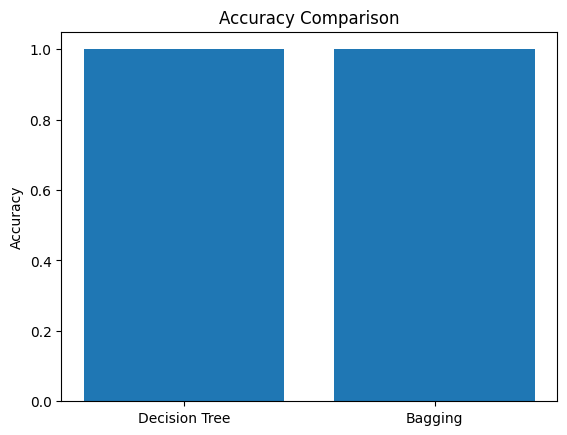

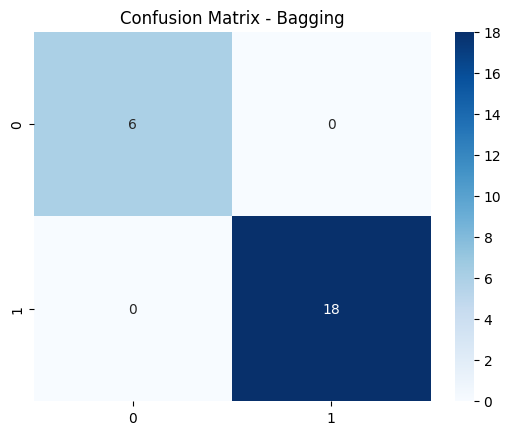

In [ ]:
# SCENARIO 1 : BAGGING - DIABETES PREDICTION

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("/content/diabetes_bagging.csv")

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Bagging
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42)

bag.fit(X_train, y_train)
bag_pred = bag.predict(X_test)
bag_acc = accuracy_score(y_test, bag_pred)

# Accuracy comparison
plt.bar(["Decision Tree", "Bagging"], [dt_acc, bag_acc])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, bag_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Bagging")
plt.show()

SCENARIO 2 – (Boosting-AdaBoost, Gradient Boosting)

Problem Statement:
Predict whether a customer will churn.

Dataset:
Telco Customer Churn Dataset

Target Variable:
Churn (Yes/No)

Input Features:
Tenure, Monthly Charges, Contract Type


Saving churn_boosting.csv to churn_boosting (2).csv
AdaBoost Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


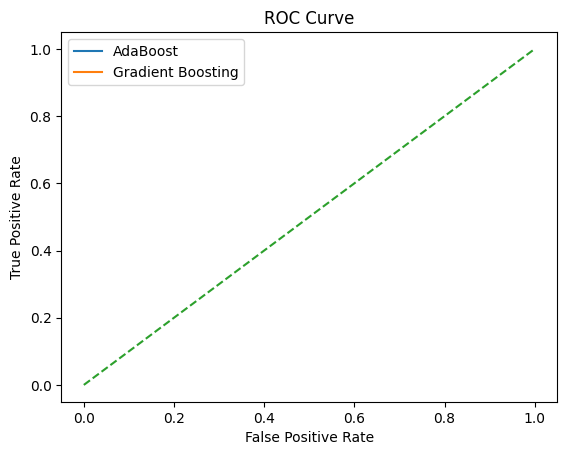

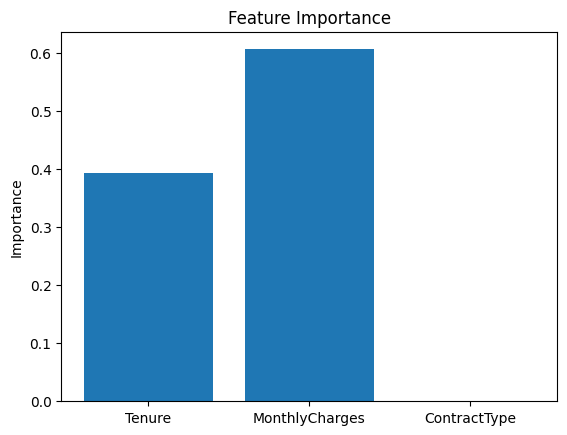

In [2]:
# SCENARIO 2 – (Boosting-AdaBoost, Gradient Boosting)

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

# Upload dataset
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])

# Select required columns
data = data[['Tenure','MonthlyCharges','ContractType','Churn']]
data.dropna(inplace=True)

# Encode categorical variables
data['ContractType'] = LabelEncoder().fit_transform(data['ContractType'])
data['Churn'] = LabelEncoder().fit_transform(data['Churn'])

# Features and target
X = data[['Tenure','MonthlyCharges','ContractType']]
y = data['Churn']

# Feature scaling
X = StandardScaler().fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train models
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Accuracy comparison
ada_acc = accuracy_score(y_test, ada.predict(X_test))
gb_acc = accuracy_score(y_test, gb.predict(X_test))

print("AdaBoost Accuracy:", ada_acc)
print("Gradient Boosting Accuracy:", gb_acc)

# ROC Curve
ada_prob = ada.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label="AdaBoost")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature Importance
features = ['Tenure','MonthlyCharges','ContractType']

plt.figure()
plt.bar(features, gb.feature_importances_)
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

SCENARIO 3 – Random Forest

Problem Statement:
Predict whether a person earns >50K salary.

Dataset:
Adult Income Dataset

Target Variable:
Income (>50K or <=50K)

Input Features:
Age, Education, Occupation, Hours-per-week


Saving income_random_forest.csv to income_random_forest (2).csv
Columns in dataset:
Index(['age', 'educationyears', 'hoursperweek', 'experience', 'income'], dtype='object')
Model Accuracy: 1.0


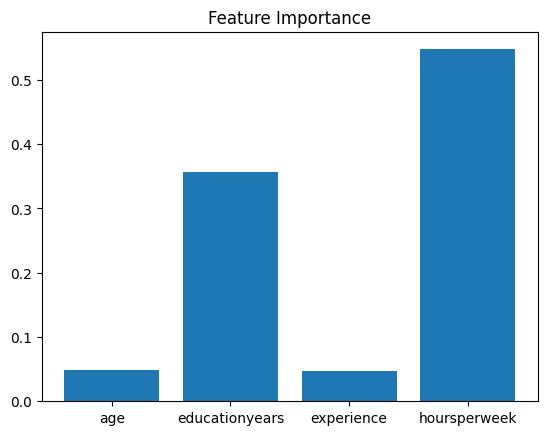

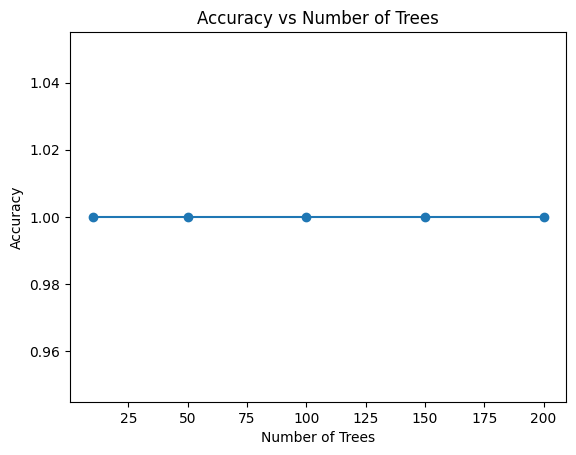

In [5]:
# SCENARIO 3 – Random Forest

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Upload dataset
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])

# Fix column names (remove spaces & lowercase)
data.columns = data.columns.str.strip().str.lower().str.replace('-', '_')

print("Columns in dataset:")
print(data.columns)

# Select required columns (auto-matched)
data = data[['age','educationyears','experience','hoursperweek','income']]
data.dropna(inplace=True)

# Encode categorical columns
le = LabelEncoder()
data['educationyears'] = le.fit_transform(data['educationyears'])
data['income'] = le.fit_transform(data['income'])

# Features and target
X = data[['age','educationyears','experience','hoursperweek']]
y = data['income']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Tune number of trees
tree_range = [10, 50, 100, 150, 200]
accuracies = []

for n in tree_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, preds))

# Final model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, preds))

# Feature Importance plot
plt.figure()
plt.bar(X.columns, rf.feature_importances_)
plt.title("Feature Importance")
plt.show()

# Accuracy vs Number of Trees
plt.figure()
plt.plot(tree_range, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

SCENARIO 4 – Stacking

Problem Statement:
Predict heart disease presence.

Dataset:
Heart Disease Dataset

Target Variable:
Presence of Heart Disease (0/1)

Input Features:
Cholesterol, Max Heart Rate, Age


Saving heart_stacking.csv to heart_stacking (1).csv
Columns: Index(['age', 'cholesterol', 'maxheartrate', 'restingbp', 'heartdisease'], dtype='object')
Logistic Regression Accuracy: 0.625
SVM Accuracy: 0.625
Decision Tree Accuracy: 0.6666666666666666
Stacking Accuracy: 0.6666666666666666


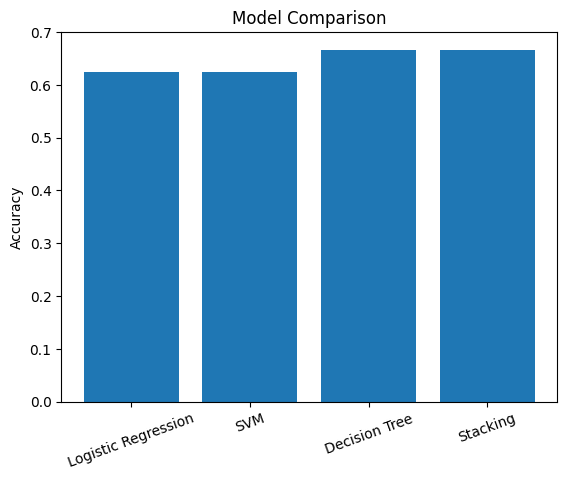

In [7]:
# SCENARIO 4 – Stacking

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

# Upload dataset
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])

# Clean column names
data.columns = data.columns.str.strip().str.lower().str.replace('-', '_')

print("Columns:", data.columns)

# Select required features
data = data[['cholesterol','maxheartrate','age','heartdisease']]
data.dropna(inplace=True)

# Features and target
X = data[['cholesterol','maxheartrate','age']]
y = data['heartdisease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Base models
lr = LogisticRegression()
svm = SVC(probability=True)
dt = DecisionTreeClassifier(random_state=42)

# Train individual models
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Predictions
lr_acc = accuracy_score(y_test, lr.predict(X_test))
svm_acc = accuracy_score(y_test, svm.predict(X_test))
dt_acc = accuracy_score(y_test, dt.predict(X_test))

# Stacking model
stack_model = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm),
        ('dt', dt)
    ],
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)
stack_acc = accuracy_score(y_test, stack_model.predict(X_test))

# Print accuracies
print("Logistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svm_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Stacking Accuracy:", stack_acc)

# Model comparison bar chart
models = ['Logistic Regression','SVM','Decision Tree','Stacking']
scores = [lr_acc, svm_acc, dt_acc, stack_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

SCENARIO 5 – SMOTE

Problem Statement:
Detect fraudulent transactions.

Dataset:
Credit Card Fraud Detection Dataset

Target Variable:
Fraud (0 = Normal, 1 = Fraud)

Input Features:
Transaction Amount, Time, PCA features


Saving fraud_smote.csv to fraud_smote.csv
Fraud
0    110
1     10
Name: count, dtype: int64


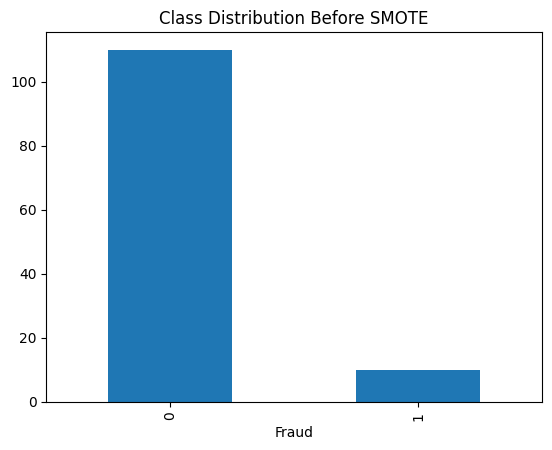

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24

Fraud
1    88
0    88
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


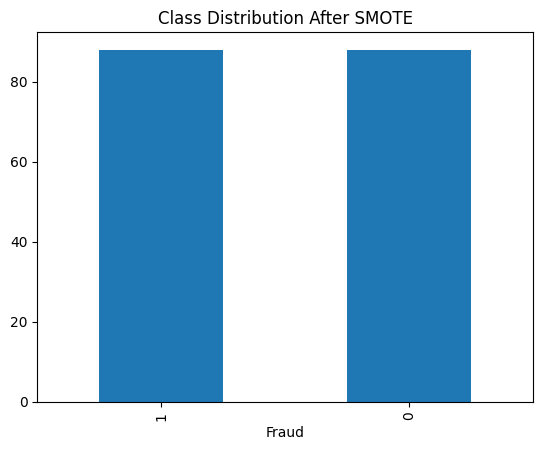

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        22
           1       0.00      0.00      0.00         2

    accuracy                           0.75        24
   macro avg       0.45      0.41      0.43        24
weighted avg       0.83      0.75      0.79        24



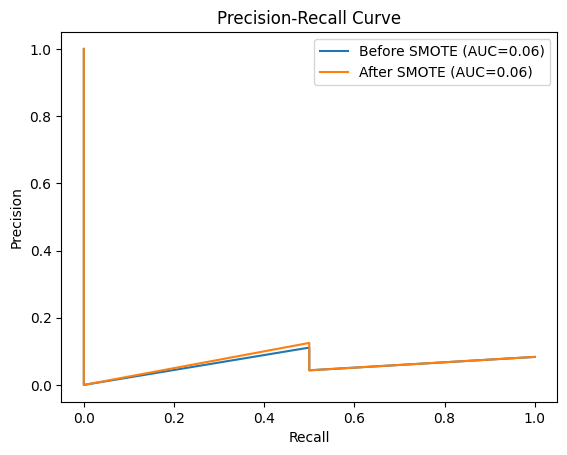

In [8]:
# SCENARIO 5 – SMOTE

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

# Upload dataset
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])

data.columns = data.columns.str.strip()

# Features and target
X = data.drop('Fraud', axis=1)
y = data['Fraud']

# Class distribution before SMOTE
print(y.value_counts())

plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.show()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model before SMOTE
model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
y_prob_before = model_before.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_before))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(pd.Series(y_train_sm).value_counts())

plt.figure()
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.show()

# Model after SMOTE
model_after = LogisticRegression(max_iter=1000)
model_after.fit(X_train_sm, y_train_sm)

y_pred_after = model_after.predict(X_test)
y_prob_after = model_after.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_after))

# Precision-Recall curve
precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_before)
precision_a, recall_a, _ = precision_recall_curve(y_test, y_prob_after)

auc_before = auc(recall_b, precision_b)
auc_after = auc(recall_a, precision_a)

plt.figure()
plt.plot(recall_b, precision_b, label=f'Before SMOTE (AUC={auc_before:.2f})')
plt.plot(recall_a, precision_a, label=f'After SMOTE (AUC={auc_after:.2f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()